In [1]:
!pip install deepface


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.8 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()


Saving NTR-696x477.jpg to NTR-696x477.jpg
Saving Ram-charan-Ramraju-1-1.jpg to Ram-charan-Ramraju-1-1.jpg
Saving WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4 to WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4


In [3]:
import pandas as pd

data = {
    'name': ['ntr', 'ram_charan'],   # use consistent names
    'image_path': ['NTR-696x477.jpg', 'Ram-charan-Ramraju-1-1.jpg'],  # only filenames, not /content
    'age': [42, 45],
    'address': ['Hyderabad', 'Bangalore']
}

df = pd.DataFrame(data)
df.to_csv('person_info.csv', index=False)
print("person_info.csv created successfully!")


person_info.csv created successfully!


In [4]:
!apt install libboost-all-dev
!pip install dlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libboost-all-dev is already the newest version (1.74.0.3ubuntu7).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [5]:
import os
import shutil

os.makedirs("known_faces", exist_ok=True)

for filename in uploaded:
    shutil.move(filename, f"known_faces/{filename}")


In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [7]:
import torch
import os

In [8]:
# install YOLOv5
%cd {HOME}
!git clone https://github.com/ultralytics/yolov5

%cd {HOME}/yolov5
!pip install -r requirements.txt

from IPython import display
display.clear_output()

In [9]:
# install YOLOv8
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.187 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/107.7 GB disk)


In [10]:
# install Detectron2
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

from IPython import display
display.clear_output()

import detectron2
print("detectron2:", detectron2.__version__)

detectron2: 0.6


In [11]:
# install Supervision
!pip install supervision

from IPython import display
display.clear_output()

import supervision as sv
print("supervision", sv.__version__)

supervision 0.26.1


In [12]:
from ultralytics import YOLO
model = YOLO ('yolov8s.pt')

Saving NTR-696x477.jpg to NTR-696x477.jpg
Saving Ram-charan-Ramraju-1-1.jpg to Ram-charan-Ramraju-1-1.jpg
Saving WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4 to WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4

0: 896x1280 1 person, 2626.7ms
Speed: 74.8ms preprocess, 2626.7ms inference, 43.7ms postprocess per image at shape (1, 3, 896, 1280)


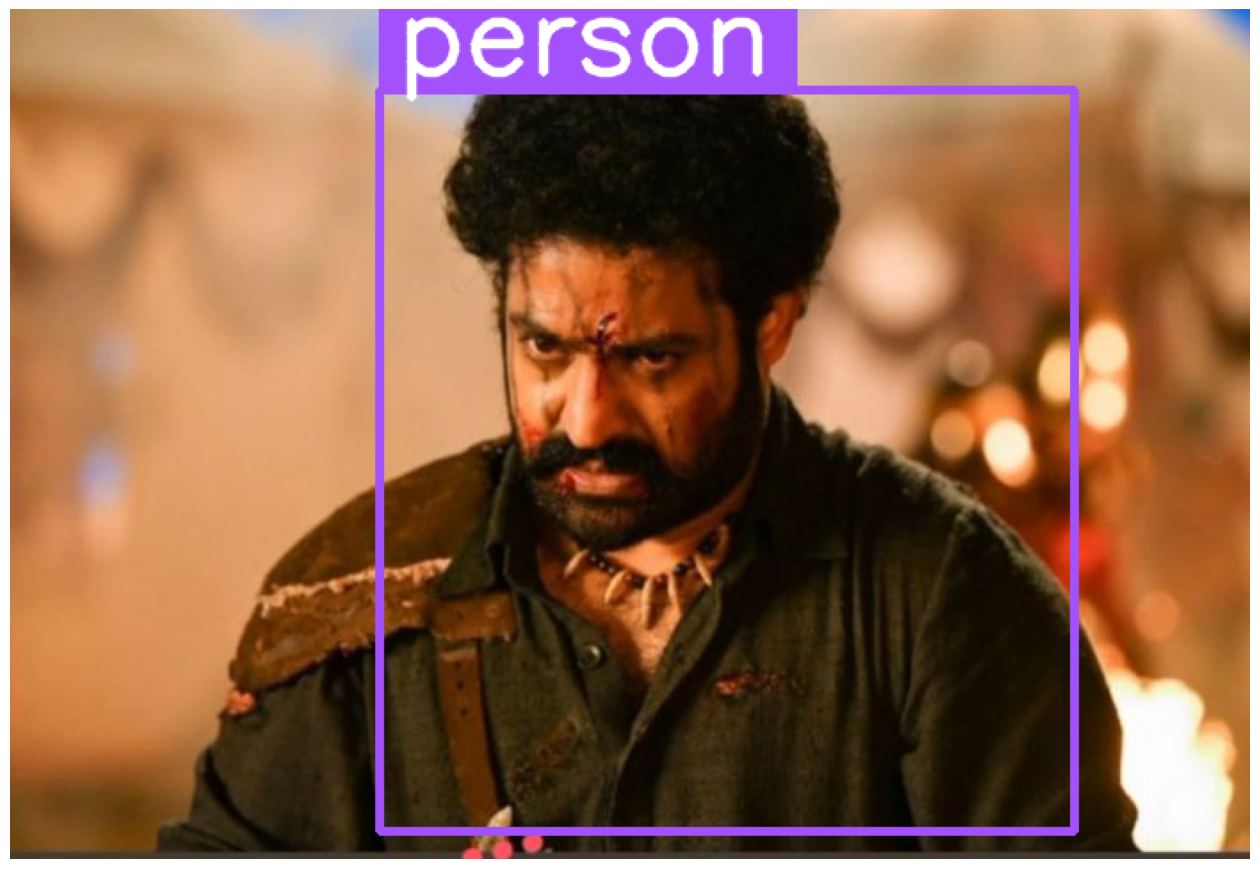

In [13]:
import supervision as sv
%matplotlib inline
import numpy as np

# If you want to upload video manually
from google.colab import files

uploaded = files.upload()  # this will let you upload your video file manually
video_path = list(uploaded.keys())[0]  # get uploaded file name

## extract video frames
generator = sv.get_video_frames_generator(video_path)

# process every 5th frame (you can change 5 → 10, 20, etc.)
skip_rate = 12

for i, frame in enumerate(generator):
    if i % skip_rate != 0:  # skip frames
        continue

    # detect
    results = model(frame, imgsz=1280)[0]
    detections = sv.Detections.from_ultralytics(results)

    # annotate
    box_annotator = sv.BoxAnnotator(thickness=4)
    label_annotator = sv.LabelAnnotator(text_thickness=4, text_scale=2)
    frame = box_annotator.annotate(scene=frame, detections=detections)
    frame = label_annotator.annotate(scene=frame, detections=detections)

    # show frame
    sv.plot_image(frame, (16, 16))
    break  # remove this if you want to keep processing more frames


In [14]:
from deepface import DeepFace
import cv2
import uuid
import os

def get_face_info(face_img):
    try:
        # Save temp face crop as an image file
        temp_path = f"temp_face_{uuid.uuid4().hex}.jpg"
        cv2.imwrite(temp_path, face_img)

        # Try to find the identity in known_faces
        result = DeepFace.find(img_path=temp_path, db_path="known_faces", enforce_detection=False)

        if len(result) > 0 and len(result[0]) > 0:
            identity = os.path.basename(result[0].iloc[0]['identity'])
            name = os.path.splitext(identity)[0]
        else:
            name = "Unknown"

        # Get age estimate
        analysis = DeepFace.analyze(img_path=temp_path, actions=["age"], enforce_detection=False)
        age = analysis[0]['age']

        os.remove(temp_path)  # Clean up
        return name, age, "Unknown Address"

    except Exception as e:
        print("Error in DeepFace:", e)
        return "Unknown", "Unknown", "Unknown"


25-08-27 18:29:02 - Directory /root/.deepface has been created
25-08-27 18:29:02 - Directory /root/.deepface/weights has been created


In [15]:
from google.colab import files

# Upload video manually
uploaded = files.upload()
video_path = list(uploaded.keys())[0]  # gets filename of uploaded video

# Use uploaded video
generator = sv.get_video_frames_generator(video_path)


Saving NTR-696x477.jpg to NTR-696x477 (1).jpg
Saving Ram-charan-Ramraju-1-1.jpg to Ram-charan-Ramraju-1-1 (1).jpg
Saving WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4 to WhatsApp Video 2025-08-27 at 20.14.59_b8728480 (1).mp4



0: 736x1280 3 persons, 3512.2ms
Speed: 16.7ms preprocess, 3512.2ms inference, 6.5ms postprocess per image at shape (1, 3, 736, 1280)


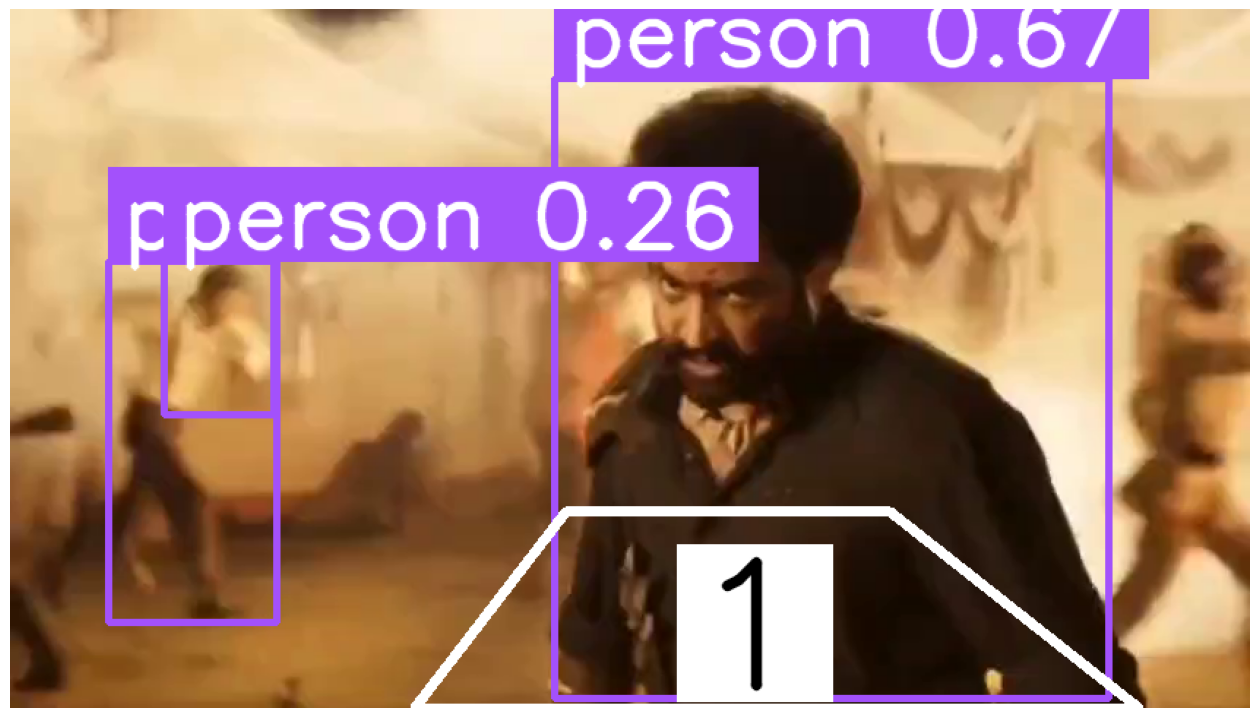

In [16]:
import supervision as sv
import numpy as np

# define polygon in normalized coordinates (0-1)
# e.g. [x_ratio, y_ratio] where x_ratio = x / width, y_ratio = y / height
normalized_polygon = np.array([
    [1725/3840, 1550/2160],
    [2725/3840, 1550/2160],
    [3500/3840, 2160/2160],
    [1250/3840, 2160/2160]
])

# load video info
video_path = '/content/WhatsApp Video 2025-08-27 at 20.14.59_b8728480 (1).mp4'  # change path if needed
video_info = sv.VideoInfo.from_video_path(video_path)
width, height = video_info.resolution_wh

# scale polygon to actual resolution
polygon = (normalized_polygon * np.array([width, height])).astype(int)

# initiate zone
zone = sv.PolygonZone(polygon=polygon)

# initiates annotators
box_annotator = sv.BoxAnnotator(thickness=4)
label_annotator = sv.LabelAnnotator(text_thickness=4, text_scale=2)
zone_annotator = sv.PolygonZoneAnnotator(
    zone=zone,
    color=sv.Color.WHITE,
    thickness=6,
    text_thickness=6,
    text_scale=4
)

# extract one video frame
generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_ultralytics(results)
detections = detections[detections.class_id == 0]
zone.trigger(detections=detections)

# annotate
labels = [
    f'{model.names[class_id]} {confidence:0.2f}'
    for _, _, confidence, class_id, _, _ in detections
]
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)
frame = zone_annotator.annotate(scene=frame)

# show frame
sv.plot_image(frame, (16, 16))


model_final_f10217.pkl: 178MB [00:01, 114MB/s]                           


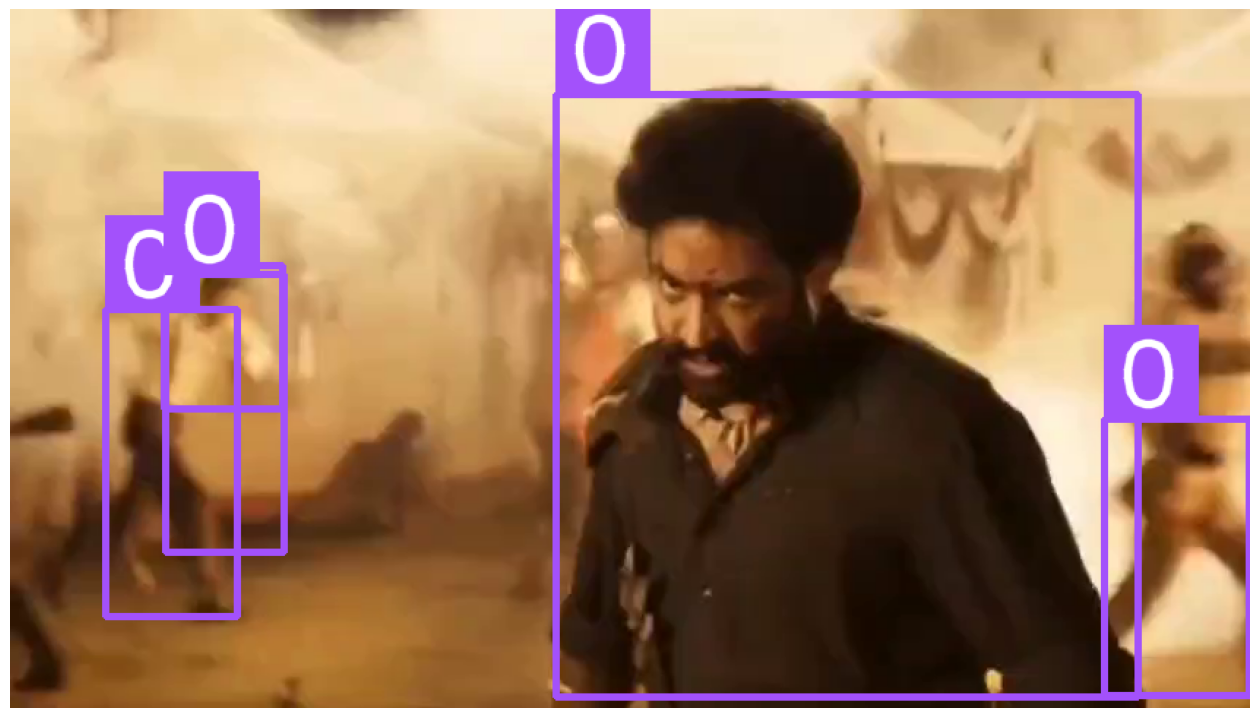

In [17]:
# import required libraries
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml')
# Explicitly set the device to CPU
cfg.MODEL.DEVICE = "cpu"  # This line forces the model to run on CPU
predictor = DefaultPredictor(cfg)

generator = sv.get_video_frames_generator ('/content/WhatsApp Video 2025-08-27 at 20.14.59_b8728480 (1).mp4')
iterator = iter (generator)
frame = next (iterator)

# detect
outputs = predictor (frame)
detections = sv.Detections(xyxy = outputs['instances'].pred_boxes.tensor.cpu().numpy(),
                            confidence = outputs ['instances'].scores.cpu().numpy(),
                            class_id = outputs ['instances'].pred_classes.cpu().numpy().astype(int))


# annotate
box_annotator = sv.BoxAnnotator (thickness = 4)
label_annotator = sv.LabelAnnotator (text_thickness = 4, text_scale = 2)
frame = box_annotator.annotate (scene = frame, detections = detections)
frame = label_annotator.annotate (scene = frame, detections = detections)

sv.plot_image (frame, (16, 16))

25-08-27 18:39:31 - Searching temp_face_eb070edc27684c8ca0592053adb86647.jpg in 3 length datastore
25-08-27 18:39:31 - find function duration 0.582416296005249 seconds
25-08-27 18:39:31 - Searching temp_face_25f42067287c4aee8a86c6fd50248b7e.jpg in 3 length datastore
25-08-27 18:39:32 - find function duration 0.5525822639465332 seconds
25-08-27 18:39:32 - Searching temp_face_7d9e36f2812541e1bf885cb5cc668fc0.jpg in 3 length datastore
25-08-27 18:39:33 - find function duration 0.5816409587860107 seconds
Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.98)


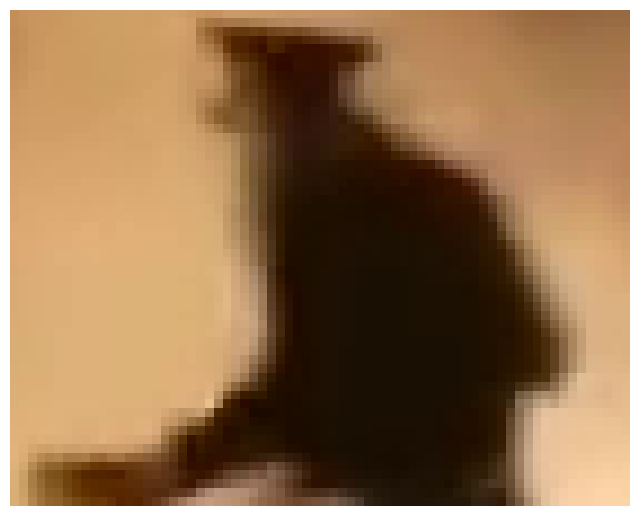

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.94)


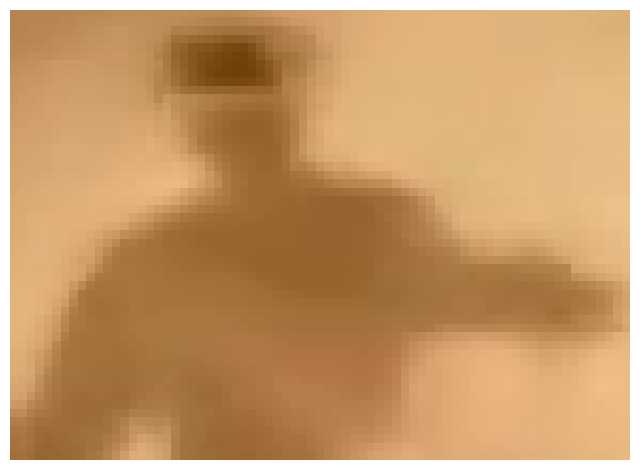

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.85)


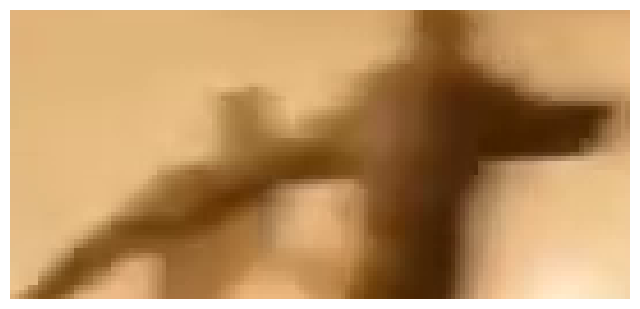

In [18]:
import supervision as sv
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from deepface import DeepFace
import os
import cv2
import uuid
import pandas as pd
from IPython.display import clear_output

# Load external CSV database
person_df = pd.read_csv("person_info.csv")

# Setup detectron2
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml')
cfg.MODEL.DEVICE = "cpu"
predictor = DefaultPredictor(cfg)

# Frame skipping value
SKIP_FRAMES = 12

# Helper function to extract person info
def get_face_info(face_img):
    try:
        temp_path = f"temp_face_{uuid.uuid4().hex}.jpg"
        cv2.imwrite(temp_path, face_img)

        result = DeepFace.find(img_path=temp_path, db_path="known_faces", enforce_detection=False)
        name, age, address = "Unknown", "Unknown", "Unknown"

        if len(result) > 0 and len(result[0]) > 0:
            identity_path = result[0].iloc[0]['identity']
            identity_file = os.path.basename(identity_path)
            matched_row = person_df[person_df["image_path"] == identity_file]

            if not matched_row.empty:
                person = matched_row.iloc[0]
                name = person['name']
                age = person['age']
                address = person['address']

        os.remove(temp_path)
        return name, age, address

    except Exception as e:
        print("DeepFace error:", e)
        return "Unknown", "Unknown", "Unknown"

# Process video
video_path = '/content/WhatsApp Video 2025-08-27 at 20.14.59_b8728480.mp4'

try:
    generator = sv.get_video_frames_generator(video_path)
    iterator = iter(generator)

    for i, frame in enumerate(iterator):
        if i % SKIP_FRAMES != 0:
            continue

        outputs = predictor(frame)
        detections = sv.Detections(
            xyxy=outputs["instances"].pred_boxes.tensor.cpu().numpy(),
            confidence=outputs["instances"].scores.cpu().numpy(),
            class_id=outputs['instances'].pred_classes.cpu().numpy().astype(int)
        )
        detections = detections[detections.class_id == 0]  # only persons

        matched_faces = []

        for box, conf in zip(detections.xyxy, detections.confidence):
            x1, y1, x2, y2 = map(int, box)
            face_crop = frame[y1:int(y1 + 0.4 * (y2 - y1)), x1:x2]

            if face_crop.size == 0:
                continue

            name, age, address = get_face_info(face_crop)

            # Only keep NTR and Ram Charan
            if name.lower() in ["ntr", "ram_charan"]:
                detail = {"name": name, "age": age, "address": address, "confidence": conf, "box": (x1, y1, x2, y2)}
                matched_faces.append(detail)

        for mf in matched_faces:
            print(f"Detected: {mf['name']} "
                  f"(Age: {mf['age']}, Address: {mf['address']}, Score: {mf['confidence']:.2f})")

            x1, y1, x2, y2 = mf["box"]
            face_crop = frame[y1:int(y1 + 0.4 * (y2 - y1)), x1:x2]

            if face_crop.size > 0:
                filename = f"{mf['name']}_{i}.jpg"
                cv2.imwrite(filename, face_crop)
                sv.plot_image(face_crop, (8, 8))

        clear_output(wait=True)

except Exception as e:
    print(f"Error processing {video_path}: {e}")




25-08-27 19:21:29 - Searching temp_face_d20abbe2ce1b4580b89ce603df23d1c0.jpg in 3 length datastore
25-08-27 19:21:30 - find function duration 0.5732467174530029 seconds
25-08-27 19:21:30 - Searching temp_face_9a22168c796c4b03b24523063c14d56f.jpg in 3 length datastore
25-08-27 19:21:31 - find function duration 0.5514979362487793 seconds
25-08-27 19:21:31 - Searching temp_face_50f2fecc4c154e20b3213ae14cc5a23e.jpg in 3 length datastore
25-08-27 19:21:31 - find function duration 0.5745224952697754 seconds
25-08-27 19:21:31 - Searching temp_face_01181c243eac4659aa3991e559fa116e.jpg in 3 length datastore
25-08-27 19:21:32 - find function duration 0.5606725215911865 seconds
25-08-27 19:21:32 - Searching temp_face_83ed9316f46644d2ba311dcfa380fdf2.jpg in 3 length datastore
25-08-27 19:21:32 - find function duration 0.5793657302856445 seconds
Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.98)


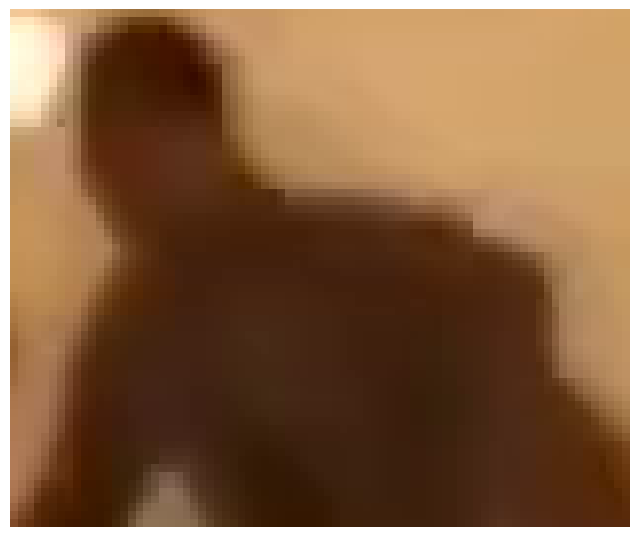

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.96)


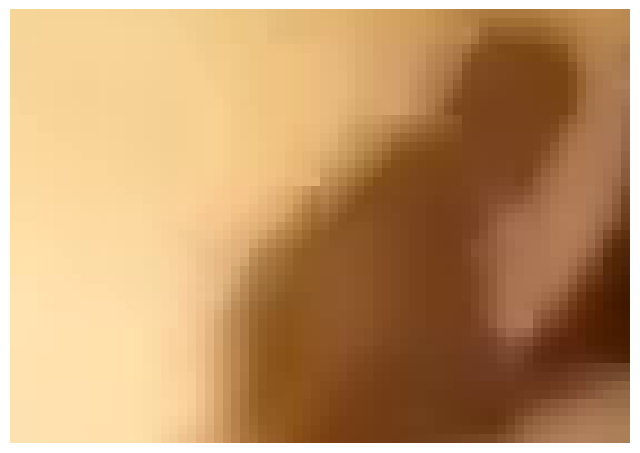

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.96)


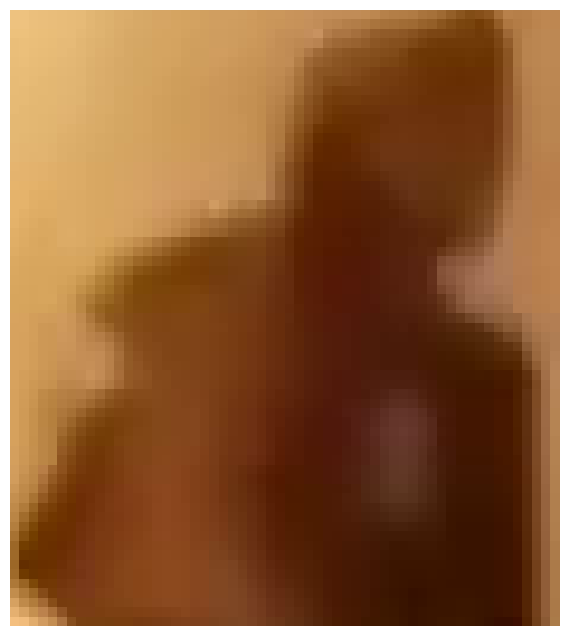

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.95)


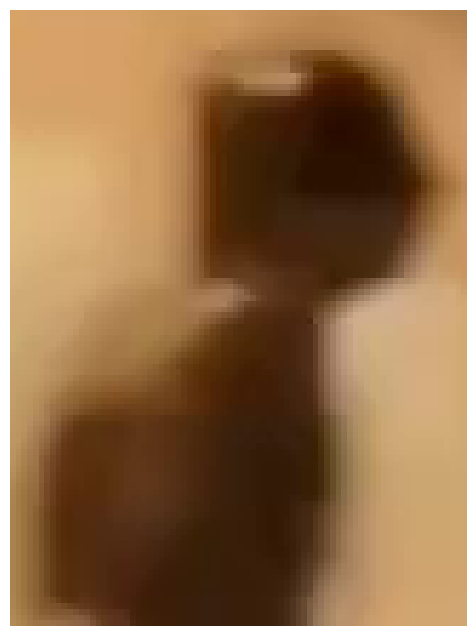

Detected: ram_charan (Age: 45, Address: Bangalore, Score: 0.61)


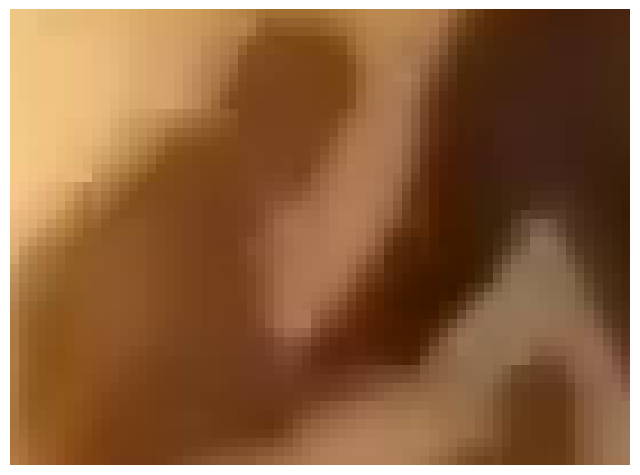

In [19]:
from IPython.display import clear_output
import tempfile
import os

video_path = '/content/WhatsApp Video 2025-08-27 at 20.14.59_b8728480 (1).mp4'

# Save the uploaded file to a temporary location
if video_path in uploaded:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as tmp_file:
        tmp_file.write(uploaded[video_path])
        temp_video_path = tmp_file.name
    video_path = temp_video_path
else:
    # If not in uploaded, assume it's a path that should work (e.g., from Drive)
    print(f"Using existing video path: {video_path}")


generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)

for i, frame in enumerate(iterator):
    outputs = predictor(frame)
    detections = sv.Detections(
        xyxy=outputs["instances"].pred_boxes.tensor.cpu().numpy(),
        confidence=outputs["instances"].scores.cpu().numpy(),
        class_id=outputs["instances"].pred_classes.cpu().numpy().astype(int)
    )
    detections = detections[detections.class_id == 0]  # only persons

    matched_faces = []

    for box, conf in zip(detections.xyxy, detections.confidence):
        x1, y1, x2, y2 = map(int, box)
        face_crop = frame[y1:int(y1 + 0.4 * (y2 - y1)), x1:x2]

        if face_crop.size == 0:
            continue

        name, age, address = get_face_info(face_crop)

        # Only keep NTR and Ram Charan
        if name.lower() in ["ntr", "ram_charan"]:
            detail = {"name": name, "age": age, "address": address, "confidence": conf, "box": (x1, y1, x2, y2)}
            matched_faces.append(detail)

    # Output only NTR and Ram Charan
    for mf in matched_faces:
        print(f"Detected: {mf['name']} "
              f"(Age: {mf['age']}, Address: {mf['address']}, Score: {mf['confidence']:.2f})")

        x1, y1, x2, y2 = mf["box"]
        face_crop = frame[y1:int(y1 + 0.4 * (y2 - y1)), x1:x2]

        if face_crop.size > 0:
            filename = f"{mf['name']}_{i}.jpg"
            cv2.imwrite(filename, face_crop)  # save only their face
            sv.plot_image(face_crop, (8, 8))  # display face only

    clear_output(wait=True)

# Clean up the temporary file
if 'temp_video_path' in locals() and os.path.exists(temp_video_path):
    os.remove(temp_video_path)